# Neural Networks: Assignment Week 2
Nea Lukumies

Assignment instructions: https://github.com/kopuj/neuralNetworks/blob/master/Assignments/Assignment_week2.md

The data is the large California housing dataset from Keras datasets. The dataset contains 8 features and a target variable which is the median house value for California districts. The dataset does not include any missing values.

Features:

    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

The goal is to first achieve a neural network architecture that shows clear signs of overfitting, and then use regularization techniques to reduce the overfitting. The performance of the model is evaluated using mean absolute error (MAE) on the test set. 

The target variable (median house value) is scaled by dividing it by 10^5 to make the values more manageable for the neural network. The features are also normalized using the mean and standard deviation of the training set.

The data is first divided into training, validation and test sets. A small training set (4128) is used to make overfitting more likely, and a larger validation set (12384) is used to clearly see the overfitting in the training and validation curves. Ideally, the divide would be more balanced when trying to achieve the best possible accuracy, but here the goal is to see the effect of regularization on overfitting. The test set is used to evaluate the final performance of the model after regularization (size: 4128).

In [25]:
import numpy as np
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense, Input, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from keras.datasets import california_housing
from keras.regularizers import l2

(x_train_full, y_train_full), (x_test, y_test) = california_housing.load_data(
    version='large', test_split=0.2
)

# Train / validation split
x_train = x_train_full[:4128]
y_train = y_train_full[:4128]

x_val = x_train_full[4128:]
y_val = y_train_full[4128:]

mean = x_train.mean(axis=0)
std = x_train.std(axis=0)
x_train = (x_train - mean) / std
x_val = (x_val - mean) / std
x_test = (x_test - mean) / std

y_train = y_train / 100000
y_val   = y_val / 100000
y_test  = y_test / 100000

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(4128, 8) (4128,)
(12384, 8) (12384,)
(4128, 8) (4128,)


To achieve a model with overfitting, a few differenct architectures were tested. The amount of layers varied between 2 and 8 and the amount of neurons varied between 64 and 512. Several batch sizes and epoch amounts were also tested. The final baseline architecture was chosen so that the training time would be reasonable for this assignment:

- 3 hidden layers with 256 neurons each
- 300 epochs
- batch size of 64

In [26]:
baseline_model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1)
])

baseline_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = baseline_model.fit(
    x_train, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=0
)

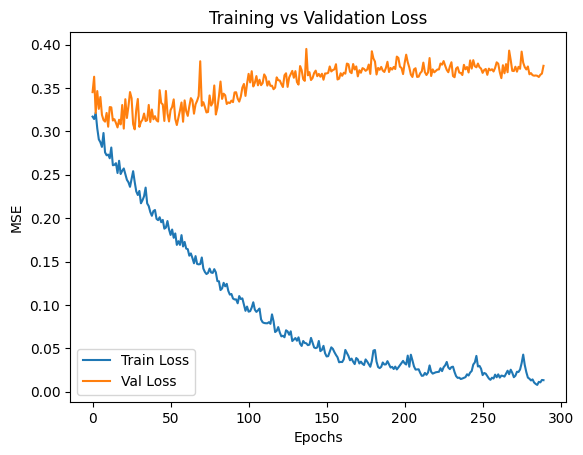

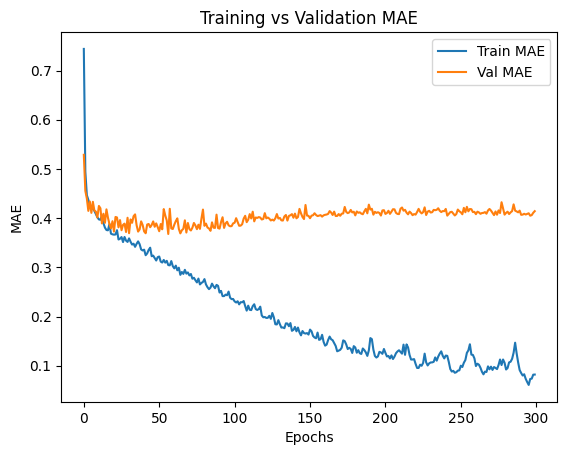

In [27]:
# Loss (MSE)
plt.plot(history.history['loss'][10:], label='Train Loss')
plt.plot(history.history['val_loss'][10:], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

# MAE
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.title('Training vs Validation MAE')
plt.show()

As seen on the curves above, the validation loss starts increasing after about 50 epochs, while the training loss continues to decrease. This is a clear sign of overfitting, so the model is a good baseline for testing regularization techniques.

The following regularization techniques were used to reduce overfitting:

    - L2 regularization with a factor of 0.01 and 0.001
    - Dropout with a rate of 0.2, 0.3 and 0.5
    - Batch normalization
    - Early stopping with a patience of 10 epochs

L2 regularization smoothed out the training and validation curves quite nicely and reduced overfitting. L2 regularization means that the weights of the model are smaller, making the model less likely to overfit. Dropout also reduced overfitting, with 0.2 rate working best. Dropout works by leaving out random neurons during training. Batch normalization did not have that much of an effect on overfitting. Early stopping needed L2 regularization to smooth the learning curves, otherwise it stopped way too early. With L2 regularization the loss curves were smoother and early stopping could be used with a lower patience. 

The final architecture with regularization was the same as the baseline architecture, but with L2 regularization (factor 0.01) and dropout (rate 0.2) added to each hidden layer, and early stopping with a patience of 10 epochs. Early stopping was set to be used with "restore_best_weights=True", which chooses the weights from the epoch with the best validation loss, so the final model is not necessarily the one from the last epoch.

In [28]:
regularized_model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.2),
    Dense(1)
])

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
regularized_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

regularized_history = regularized_model.fit(
    x_train, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=0
)

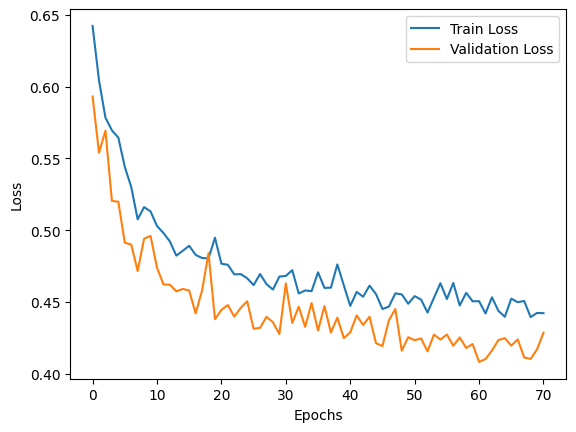

In [29]:
plt.plot(regularized_history.history['loss'][10:], label='Train Loss')
plt.plot(regularized_history.history['val_loss'][10:], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

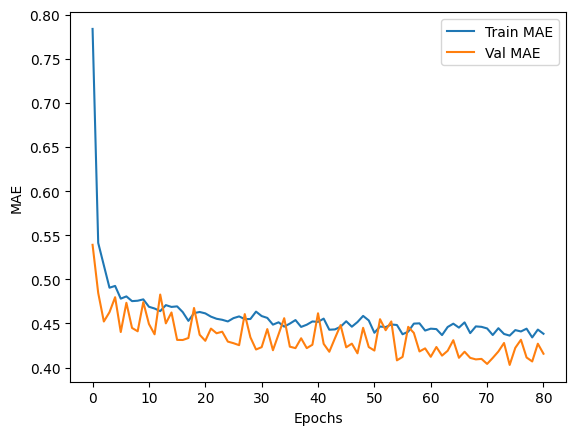

In [30]:
plt.plot(regularized_history.history['mae'], label='Train MAE')
plt.plot(regularized_history.history['val_mae'], label='Val MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.show()

In [31]:
# Accuracy of the baseline model on the test set
test_loss, test_mae = baseline_model.evaluate(x_test, y_test, verbose=0)
print("Baseline Model Test Loss:", test_loss)
print("Baseline Model Test MAE:", test_mae)
print("Baseline Model Test MAE in dollars:", test_mae * 100000)
print("\n")
# Accuracy of the regularized model on the test set
test_loss, test_mae = regularized_model.evaluate(x_test, y_test, verbose=0)
print("Regularized Model Test Loss:", test_loss)
print("Regularized Model Test MAE:", test_mae)
print("Regularized Model Test MAE in dollars:", test_mae * 100000)

Baseline Model Test Loss: 0.3759036362171173
Baseline Model Test MAE: 0.41838565468788147
Baseline Model Test MAE in dollars: 41838.56546878815


Regularized Model Test Loss: 0.43079400062561035
Regularized Model Test MAE: 0.4169778823852539
Regularized Model Test MAE in dollars: 41697.78823852539


The regularized model has about the same accuracy on the test set as the unregularized model, but the training and validation curves are much smoother and does not show signs of overfitting. Both training and validation curves are decreasing, the validation curve is lower than the training curve and the gap between the curves is not that big. All of these signs indicate that the model is not overfitting. 

The goal of the assignment was not to achieve the best possibly accuracy, but to see the effect of regularization on overfitting. The model is probably too complex for this dataset with only 8 features, so to achieve a better accuracy a simpler model could be used. Also, the training set was set to be small relative to the validation set to make overfitting more likely, so using a larger training set could also improve the accuracy. 